In [11]:
from otter import Otter
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.time import Time
import numpy as np
import pandas as pd
import cmasher as cmr
from scipy.interpolate import make_smoothing_spline, make_lsq_spline, make_interp_spline, make_splrep, make_splprep

def choose_sideband_fullband(df):
    """Function to parse the data and get the sideband data if the S/N is high enough
    otherwise it gets the fullband data"""

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def choose_fullband(df):
    """Function to get the fullband data (for light curve plots)
    """
    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()
        fullband = grp.iloc[1] # assume that each is only three long
        result.append(fullband)
        
    res = pd.DataFrame(result).reset_index()
    return res

In [12]:
import warnings
db = Otter(datadir="private-data")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    radiophot = db.get_phot(
        obs_type="radio", 
        flux_unit="erg/s/cm^2/Hz", 
        return_type="pandas", 
        query_private=True,
        classification="TDE",
        class_confidence_threshold=1
    )

sband_phot = radiophot[radiophot.filter_name == "S"]

sband_phot

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,filter_name,obs_type,upperlimit,reference,human_readable_refs,telescope
2,SDSSJ1350,3.745803e-27,0.000000e+00,58027.969622,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,True,private,private,NaN
3,SDSSJ1350,3.533384e-27,0.000000e+00,59966.416552,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,True,private,private,NaN
4,SDSSJ1350,4.425440e-27,0.000000e+00,59109.999094,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,True,private,private,NaN
1,NGC 5905,2.000000e-27,0.000000e+00,56082.328000,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,True,"['2013ApJ...763...84B', '2020SSRv..216...81A']","['2013ApJ...763...84B', '2020SSRv..216...81A']",NaN
4,eRASSt J234403-352640,2.790000e-27,2.300000e-28,59371.000000,1.153048e+08,2.600,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,2024MNRAS.528.7123G,"Goodwin, A. J. et al. (2024)",ATCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,SDSS_J0938,1.283251e-26,1.258661e-27,59961.449786,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,private,private,NaN
4,SDSS_J0938,1.113358e-26,1.228536e-27,58054.461534,9.993082e+07,3.000,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,private,private,NaN
11,SDSS_J0938,1.629100e-26,1.597000e-27,57911.795450,1.153492e+08,2.599,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,private,private,NaN
12,SDSS_J0938,1.191900e-26,1.417000e-27,57911.795450,8.820019e+07,3.399,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,private,private,NaN


In [13]:
ecle_meta = pd.read_csv("ecle-metadata.csv")

ecle_meta

,name,ra,ra_unit,dec,dec_unit,coord_bibcode,ecl_discovery_date,discovery_date,discovery_date_format,discovery_date_bibcode,redshift,redshift_bibcode,classification,classification_bibcode,radio_data,radio_data_comment,otter,otter_comments,comment
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,2020-12-15,2458745.9998032,JD,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset,Uploader:Noah Franz | Email: nfranz@arizona.edu
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024MNRAS.535.1095C,2004-02-20,2004-02-20,iso,2024MNRAS.528.7076C,0.061600,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024MNRAS.535.1095C,2005-11-08,2005-11-08,iso,2024MNRAS.528.7076C,0.073800,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024MNRAS.535.1095C,2006-12-23,2006-12-23,iso,2024MNRAS.528.7076C,0.101000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024MNRAS.535.1095C,2005-12-30,2005-12-30,iso,2024MNRAS.528.7076C,0.079500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.074000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024MNRAS.535.1095C,2008-01-19,2008-01-19,iso,2024MNRAS.528.7076C,0.050300,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024MNRAS.535.1095C,2004-02-27,2004-02-27,iso,2024MNRAS.528.7076C,0.041900,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024MNRAS.535.1095C,2006-05-21,2006-05-21,iso,2024MNRAS.528.7076C,0.104000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.036500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,WISE data from Wang+18,Uploader:Noah Franz | Email: nfranz@arizona.edu


In [14]:
sband_phot[sband_phot.name == "2018gn"]

,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,filter_name,obs_type,upperlimit,reference,human_readable_refs,telescope
3,2018gn,9.310000e-27,2.570000e-27,58643.000000,9.993082e+07,3.0,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,2024ApJ...966..136W,2024ApJ...966..136W,VLA
4,2018gn,1.300000e-26,2.100000e-27,59522.000000,9.993082e+07,3.0,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,2024ApJ...966..136W,2024ApJ...966..136W,VLA
6,2018gn,1.410000e-26,2.300000e-28,59922.000000,9.993082e+07,3.0,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,2024ApJ...966..136W,2024ApJ...966..136W,VLA
11,2018gn,8.393834e-27,1.333709e-27,60511.454135,9.993082e+07,3.0,erg/s/cm^2/Hz,MJD,nm,GHz,S,radio,False,private,private,NaN


Skipping SDSSJ1350, no discovery date!


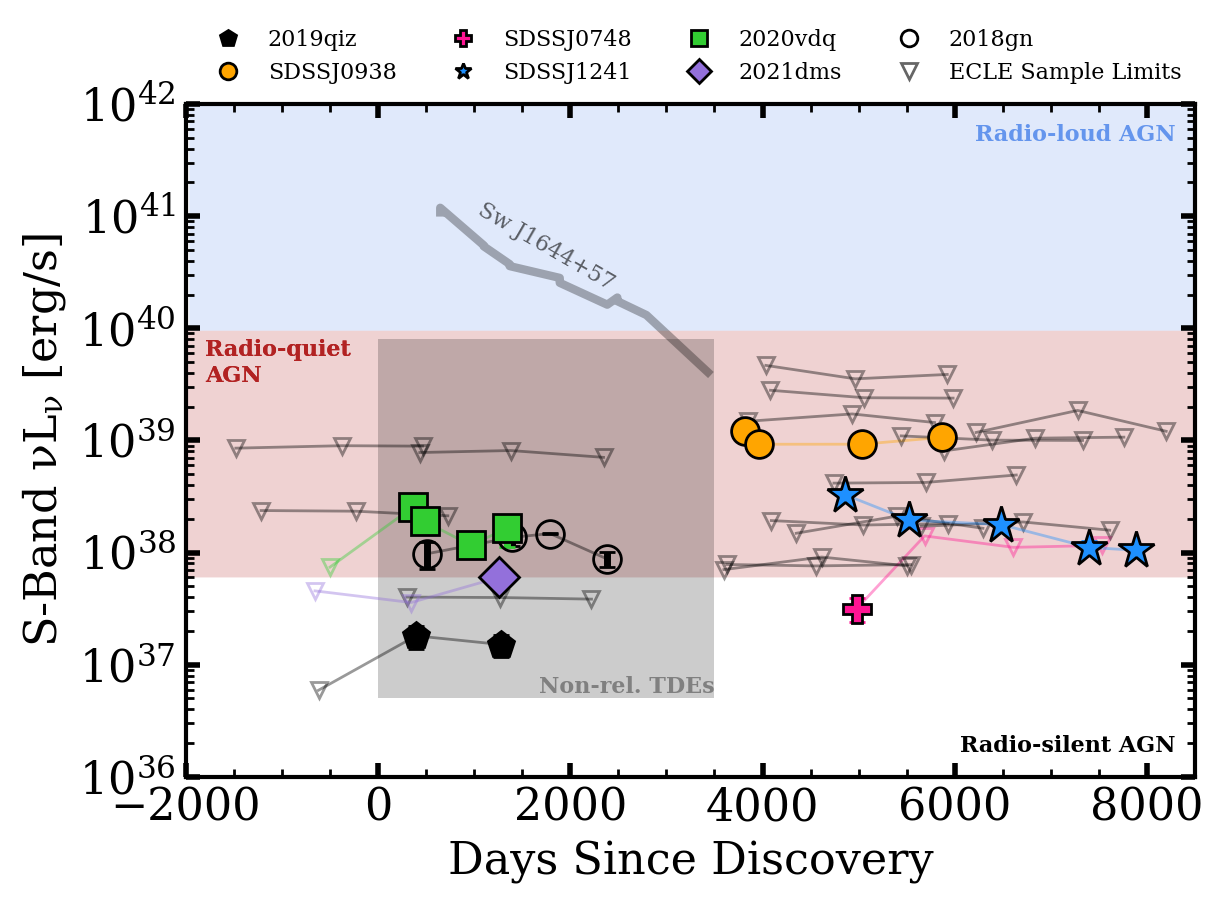

In [15]:
def flux_to_lum(flux, lum_dist):
    return flux * 4 * np.pi * lum_dist**2

fig, ax = plt.subplots()

import cmasher as cmr
cmap = cmr.tropical
colors = cmap(np.linspace(0,1,7))

markers = {
    "2019qiz":("p", "k", 10, "k"), 
    "SDSSJ0938":("o", "orange", 10, "orange"), 
    # "SDSSJ0952":("X", colors[3]), 
    "SDSSJ0748":("P", "deeppink", 10, "deeppink"), 
    "SDSSJ1241":("*", "dodgerblue", 14, "dodgerblue"), 
    "2020vdq":("s", "limegreen", 10, "limegreen"),
    "2021dms":("D", "mediumpurple", 10, "mediumpurple"),
    "2018gn":("o", "k", 10, "none")
}

ecle_names = set(ecle_meta["name"]).union(set(ecle_meta["name"].str.replace("_", "")))

i = 0
marki = 0
freq = 3 # GHz, for S-band
for name, grp in sband_phot.groupby("name"):

    if name not in ecle_names and name not in markers.keys() and name != "Sw J1644+57": continue

    grp = grp.sort_values("converted_date")
    grp = choose_fullband(grp)
    
    t = db.get_meta(names=name, query_private=True)[0]
    aliases = {alias["value"] for alias in t["name"]["alias"]}
    
    try:
        z = t.get_redshift()
    except KeyError:
        print(f"Skipping {t.default_name}, no redshift!")
        continue

    disc_date = t.get_discovery_date()
    if disc_date is None:
        print(f"Skipping {t.default_name}, no discovery date!")
        continue
    lum_dist = cosmo.luminosity_distance(float(z))

    if np.any(grp[~grp.upperlimit].converted_date.values < disc_date.mjd):
        print(name)
    
    lum_nu = flux_to_lum(grp.converted_flux.values*u.erg/u.s/u.cm**2/u.Hz, lum_dist)
    lum_err_nu = flux_to_lum(grp.converted_flux_err.values*u.erg/u.s/u.cm**2/u.Hz, lum_dist)
    
    grp["lum"] = (lum_nu * freq*u.GHz).to(u.erg/u.s).value
    grp["lum_err"] = (lum_err_nu * freq*u.GHz).to(u.erg/u.s).value
    
    lims = grp[grp.upperlimit]
    dets = grp[~grp.upperlimit]

    mark, ls, col, a, label, zord, ms = None, "-", "k", 0.3, None, 1, 1
    yerr = None
    plot_lims = False
    if aliases.intersection(ecle_names):
        ls = "-"
                
        a = 1
        zord = 10
        label = name.replace("_","").replace("AT", "")
        
        if label in markers:
            mark, col, ms, mfc = markers[label]
        else:
            mark, col, ms, mfc = "", "k", 1, "none"
            label = None
            
        yerr = dets.lum_err

        plot_lims = True
        i += 1

    if len(dets):
        ax.errorbar(dets.converted_date-disc_date.mjd, dets.lum, yerr=yerr, marker=mark, mfc=mfc, linestyle="none", color=col, alpha=a, label=label, zorder=zord, mec="k", ms=ms)
        marki += 1
        if plot_lims:
            ax.plot(lims.converted_date-disc_date.mjd, lims.lum, marker="v", linestyle="none", color="none", alpha=0.4, zorder=zord, mec=col)
            ax.plot(grp.converted_date-disc_date.mjd, grp.lum, linestyle=ls, color=col, marker="none", alpha=0.4, zorder=zord, lw=1)
        else:
            ax.plot(dets.converted_date-disc_date.mjd, dets.lum, linestyle=ls, color=col, marker="none", alpha=a, zorder=zord, lw=3)

    else:
        if plot_lims:
            ax.plot(lims.converted_date-disc_date.mjd, lims.lum, marker="v", linestyle="none", color="none", alpha=0.4, zorder=zord, mec=col, label=label)
            ax.plot(grp.converted_date-disc_date.mjd, grp.lum, linestyle=ls, color=col, marker="none", alpha=0.4, zorder=zord, lw=1)
        else:
            ax.plot(dets.converted_date-disc_date.mjd, dets.lum, linestyle=ls, color=col, marker="none", alpha=a, zorder=zord, lw=3)


x0, y0 = 0, 5e36
x1, y1 = 3500, 8e39
nonrel_tdes = Rectangle(
    (x0, y0),
    width=x1 - x0,
    height=y1 - y0,
    edgecolor="k",
    facecolor="k",
    alpha = 0.2,
    zorder = 1,
    ec = "none"
)
ax.add_patch(nonrel_tdes)

ax.text(
    x1, y0,
    "Non-rel. TDEs",
    color = "grey",
    ha = "right",
    va = "bottom",
    fontsize=8,
    fontweight="bold"
)

ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_ylabel(r"S-Band $\nu L_\nu$ [erg/s]")
ax.set_xlabel("Days Since Discovery")
ax.legend(
    handles = [
        Line2D([0], [0], color=c, marker=m, mec="k", linestyle="none", label=k, mfc=mfc)
        for k, (m, c, _, mfc) in markers.items()
    ] + [
        Line2D([0], [0], color="none", marker="v", mec="k", alpha=0.6, linestyle="none", label="ECLE Sample Limits"),
        #Line2D([0], [0], color='k', lw=3, alpha=0.3, marker="none", linestyle="-", label='TDE Sample'),
    ],
    bbox_to_anchor=(0,1), 
    loc="lower left", 
    ncols=4, 
    fontsize=8
)

# this region is from Kellerman+2016
# first "radio-loud"
nu = 6e9 * u.Hz
agn_lo = ((10**23.2*u.W/u.Hz).to(u.erg/u.s/u.Hz) * nu).value
agn_hi = ((1e28*u.W/u.Hz).to(u.erg/u.s/u.Hz) * nu).value
ax.fill_between(np.arange(*ax.get_xlim()), agn_lo, agn_hi, alpha=0.2, color="cornflowerblue", zorder=0, ec='none')

# then "radio-quiet"
agn_hi = ((10**23.2*u.W/u.Hz).to(u.erg/u.s/u.Hz) * nu).value
agn_lo = ((1e21*u.W/u.Hz).to(u.erg/u.s/u.Hz) * nu).value
ax.fill_between(np.arange(*ax.get_xlim()), agn_lo, agn_hi, alpha=0.2, color="firebrick", zorder=0, ec='none')

# then also label these
at = AnchoredText(
    "Radio-loud AGN", 
    loc="upper right", 
    frameon=False, 
    prop=dict(
        fontweight="bold", 
        color="cornflowerblue", 
        fontsize=8,
        ha="right"
    )
)
ax.add_artist(at)

at = ax.text(
    -1_800, 8e39,
    "Radio-quiet\nAGN", 
    fontweight="bold", 
    color="firebrick", 
    fontsize=8,
    ha="left",
    va="top"
    
)
ax.add_artist(at)

at = AnchoredText(
    "Radio-silent AGN", 
    loc="lower right",
    frameon=False, 
    prop=dict(
        fontweight="bold", 
        color="k", 
        fontsize=8,
        ha="right"
    )
)
ax.add_artist(at)

ax.text(
    1_000, 2e40,
    "Sw J1644+57",
    ha = "left",
    va = "bottom",
    rotation = -30,
    fontsize = 8,
    alpha = 0.6
)

ax.set_xlim(-2_000, 8_500)
ax.set_ylim(1e36, 1e42)

zs = [] #[0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
for z in zs:
    lum_dist = cosmo.luminosity_distance(z)
    lum_limit = (450*u.uJy * 5*u.GHz * lum_dist**2 * 4*np.pi).to(u.erg/u.s).value
    ax.axhline(lum_limit, linestyle=":", zorder=0)
    ax.text(-2_000, lum_limit, f"z={z}", va="bottom", ha="left", fontsize=6)

# PTF 10tqv
#tqv_z = 0.0795
#freq = 10*u.GHz

#obs_dates = [3623, 5480]
#flux = freq*np.array([70, 26.3])*u.uJy 
#flux_err = freq*np.array([7.6, 6.9])*u.uJy

#lum = flux_to_lum(flux, cosmo.luminosity_distance(tqv_z)).to(u.erg/u.s).value
#lum_err = flux_to_lum(flux_err, cosmo.luminosity_distance(tqv_z)).to(u.erg/u.s).value

# ax.plot(
#     obs_dates,
#     lum,
#     # yerr=lum_err,
#     zorder=2,
#     marker="none",
#     linestyle="-", 
#     color="k", 
#     alpha=0.3,
#     lw=3
# )

# ax.text(
#     5_550, 5e37,
#     "PTF 10tqv",
#     ha = "left",
#     va = "top",
#     rotation = -14,
#     fontsize = 8,
#     alpha = 0.6
# )

fig.savefig("Sband-lightcurves.png")
# ax.set_xlim(1e-1, ax.get_xlim()[1])

In [16]:
import warnings
db = Otter(datadir="private-data")

ecle_names = set(ecle_meta["name"]).union(set(ecle_meta["name"].str.replace("_", "")))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    radiophot = db.get_phot(
        obs_type="radio", 
        flux_unit="mJy", 
        return_type="pandas", 
        query_private=True, 
        names=list(ecle_names)
    )

(hor, tseries, rho, mag) = fig.subfigures(4, 1, height_ratios=[0.75, 0.9, 1, 1], hspace=0)

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


2018dyk has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
SDSSJ1342 has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
AT2017gge has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
AT2022fpx has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None

In [28]:
def centered_subplots(rows, subfig):
    grid_dim = max(rows)
    grid_shape = (len(rows), 2 * grid_dim)

    gs = GridSpec(
        *grid_shape,
        figure=subfig,
        wspace=0,
        hspace=0
    )

    axes = []
    first_ax = None  # reference for sharex/sharey

    for jrow, row in enumerate(rows):
        offset = 0 #grid_dim - row
        for i in range(row):
            pos = (jrow, 2 * i + offset)
            ax = subfig.add_subplot(
                gs[pos[0], pos[1]:pos[1] + 2],
                sharex=first_ax,
                sharey=first_ax
            )
            if first_ax is None:
                first_ax = ax
            axes.append(ax)

    return axes

In [18]:
from astropy.coordinates import SkyCoord
import otter

xray_data = {}
for _,row in ecle_meta.iterrows():
    rowname = row["name"]
    coord = SkyCoord(row.ra, row.dec, unit=(row.ra_unit, row.dec_unit))
    cone_search_res = db.get_meta(coords=coord, query_private=True)
    if not len(cone_search_res): 
        print(f"{rowname} is not in OTTER!")
        continue
    if len(cone_search_res) > 1:
        print("Cone search returned more than one transient! Make sure you expect this!")
        print(cone_search_res)
        # import pdb; pdb.set_trace()
        # raise
    ottername = cone_search_res[0].default_name
    try:
        xrays = db.get_phot(names=ottername, flux_unit="mJy", obs_type="xray", return_type="pandas", query_private=True, keep_raw=True)
    except otter.exceptions.FailedQueryError:
        print(f"{rowname} is in OTTER as {ottername} but doesn't have any X-rays")
        continue

    if "raw_err_detail" not in xrays:
        xrays["converted_upper"] = xrays.converted_flux_err
        xrays["converted_lower"] = xrays.converted_flux_err
        xray_data[ottername] = xrays
        continue
        
    # handle uneven error
    cleaned_phot = []

    # first, create a column of the dictionaries as a string
    # this is necessary because python dictionaries are not hashable
    xrays['raw_err_detail_str'] = xrays.raw_err_detail.astype(str)
    
    # then we can groupby the string version of the dictionaries
    for _, p in xrays.groupby(['raw_err_detail_str', 'filter_key']):
        err_detail_df = pd.DataFrame(p.raw_err_detail.iloc[0]) # convert the dict in the first row to a dataframe
        err_detail_df = err_detail_df.set_index(p.index) # align the indices
        df = pd.concat([p, err_detail_df], axis=1) # horizontally merge these dataframes
        cleaned_phot.append(df)
    
    # then combine all the data and convert the errors!
    cleaned_phot = pd.concat(cleaned_phot)
    cleaned_phot['converted_upper'] = cleaned_phot.converted_flux * (cleaned_phot.upper / cleaned_phot.raw)
    cleaned_phot['converted_lower'] = cleaned_phot.converted_flux * (cleaned_phot.lower / cleaned_phot.raw)
    
    
    xray_data[ottername] = cleaned_phot
    print(rowname, ottername, len(xrays))

xray_data

/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1072: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):


2019qiz 2019qiz 10
Cone search returned more than one transient! Make sure you expect this!
[Transient(
	Name: SDSSJ0748,
	Keys: dict_keys(['name', 'coordinate', 'date_reference', 'distance', 'classification', 'reference_alias'])
), Transient(
	Name: SDSS1737-53055-369,
	Keys: dict_keys(['name', 'coordinate', 'classification', 'reference_alias'])
)]
SDSS_J0807 SDSS_J0807 1
SDSS_J0938 SDSS_J0938 4
SDSS_J1055 SDSS_J1055 9
SDSS_J1207 SDSS_J1207 1
SDSS_J1241 SDSS_J1241 4
SDSS_J1247 SDSS_J1247 3
SDSS_J1402 SDSS_J1402 1
SDSS_J1459 is in OTTER as SDSS_J1459 but doesn't have any X-rays
SDSS_J1715 SDSS_J1715 1
SDSS_J2220 SDSS_J2220 1
SDSS_J1458 is in OTTER as SDSS_J1458 but doesn't have any X-rays
SDSS_J1238 SDSS_J1238 1
AT2022fpx 2022fpx 4
AT2021dms is in OTTER as AT2021dms but doesn't have any X-rays


2018bcb has at least one photometry point where it is unclear if a host subtraction was performed. This can be especially detrimental for UV data. Please consider filtering out UV/Optical/IR or radio rows where the corr_host column is null/None/NaN.
/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1072: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):


AT2021qth is in OTTER as 2021qth but doesn't have any X-rays
AT2021acak AT2021acak 2


/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1072: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):


AT2018dyk 2018dyk 28


/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1072: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):


AT2018gn 2018gn 13


{'2019qiz':    converted_flux  converted_flux_err  converted_date  converted_wave  \
 2        0.000012            0.000000         58857.0        2.686324   
 3        0.000221            0.000054         59588.9        2.686324   
 4        0.000786            0.000135         59589.7        2.686324   
 5        0.000470            0.000150         59854.5        2.686324   
 6        0.000291            0.000128         59874.5        2.686324   
 7        0.000158            0.000100         60121.5        2.686324   
 8        0.000155            0.000103         60273.5        2.686324   
 9        0.004322            0.000506         60273.5        2.686324   
 0        0.006384            0.001532         60365.5        2.686324   
 1        0.000201            0.000043         60366.5        2.686324   
 
    converted_freq converted_flux_unit converted_date_unit converted_wave_unit  \
 2    1.115995e+08                 mJy                 MJD                  nm   
 3    1.1

2018dyk dict_keys(['2019qiz', 'SDSSJ0748', 'SDSS_J0807', 'SDSS_J0938', 'SDSSJ0952', 'SDSS_J1055', 'SDSS_J1207', 'SDSS_J1241', 'SDSS_J1247', 'SDSSJ1342', 'SDSSJ1350', 'SDSS_J1402', 'SDSS_J1715', 'SDSS_J2220', 'SDSS_J1238', '2017gge', '2022fpx', '2022upj', '2018bcb', '2020vdq', 'AT2021acak', '2018dyk', '2018gn'])
2018dyk has xrays
0 2018dyk
AT2018dyk
2018gn dict_keys(['2019qiz', 'SDSSJ0748', 'SDSS_J0807', 'SDSS_J0938', 'SDSSJ0952', 'SDSS_J1055', 'SDSS_J1207', 'SDSS_J1241', 'SDSS_J1247', 'SDSSJ1342', 'SDSSJ1350', 'SDSS_J1402', 'SDSS_J1715', 'SDSS_J2220', 'SDSS_J1238', '2017gge', '2022fpx', '2022upj', '2018bcb', '2020vdq', 'AT2021acak', '2018dyk', '2018gn'])
2018gn has xrays
1 2018gn
AT2018gn
2019qiz dict_keys(['2019qiz', 'SDSSJ0748', 'SDSS_J0807', 'SDSS_J0938', 'SDSSJ0952', 'SDSS_J1055', 'SDSS_J1207', 'SDSS_J1241', 'SDSS_J1247', 'SDSSJ1342', 'SDSSJ1350', 'SDSS_J1402', 'SDSS_J1715', 'SDSS_J2220', 'SDSS_J1238', '2017gge', '2022fpx', '2022upj', '2018bcb', '2020vdq', 'AT2021acak', '2018dyk', 

/tmp/ipykernel_655183/1444507325.py:264: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  fig.savefig("ecle-radio-lcs.png")
/home/nfranz/.local/lib/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  func(*args, **kwargs)
/home/nfranz/.local/lib/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  fig.canvas.print_figure(bytes_io, **kw)


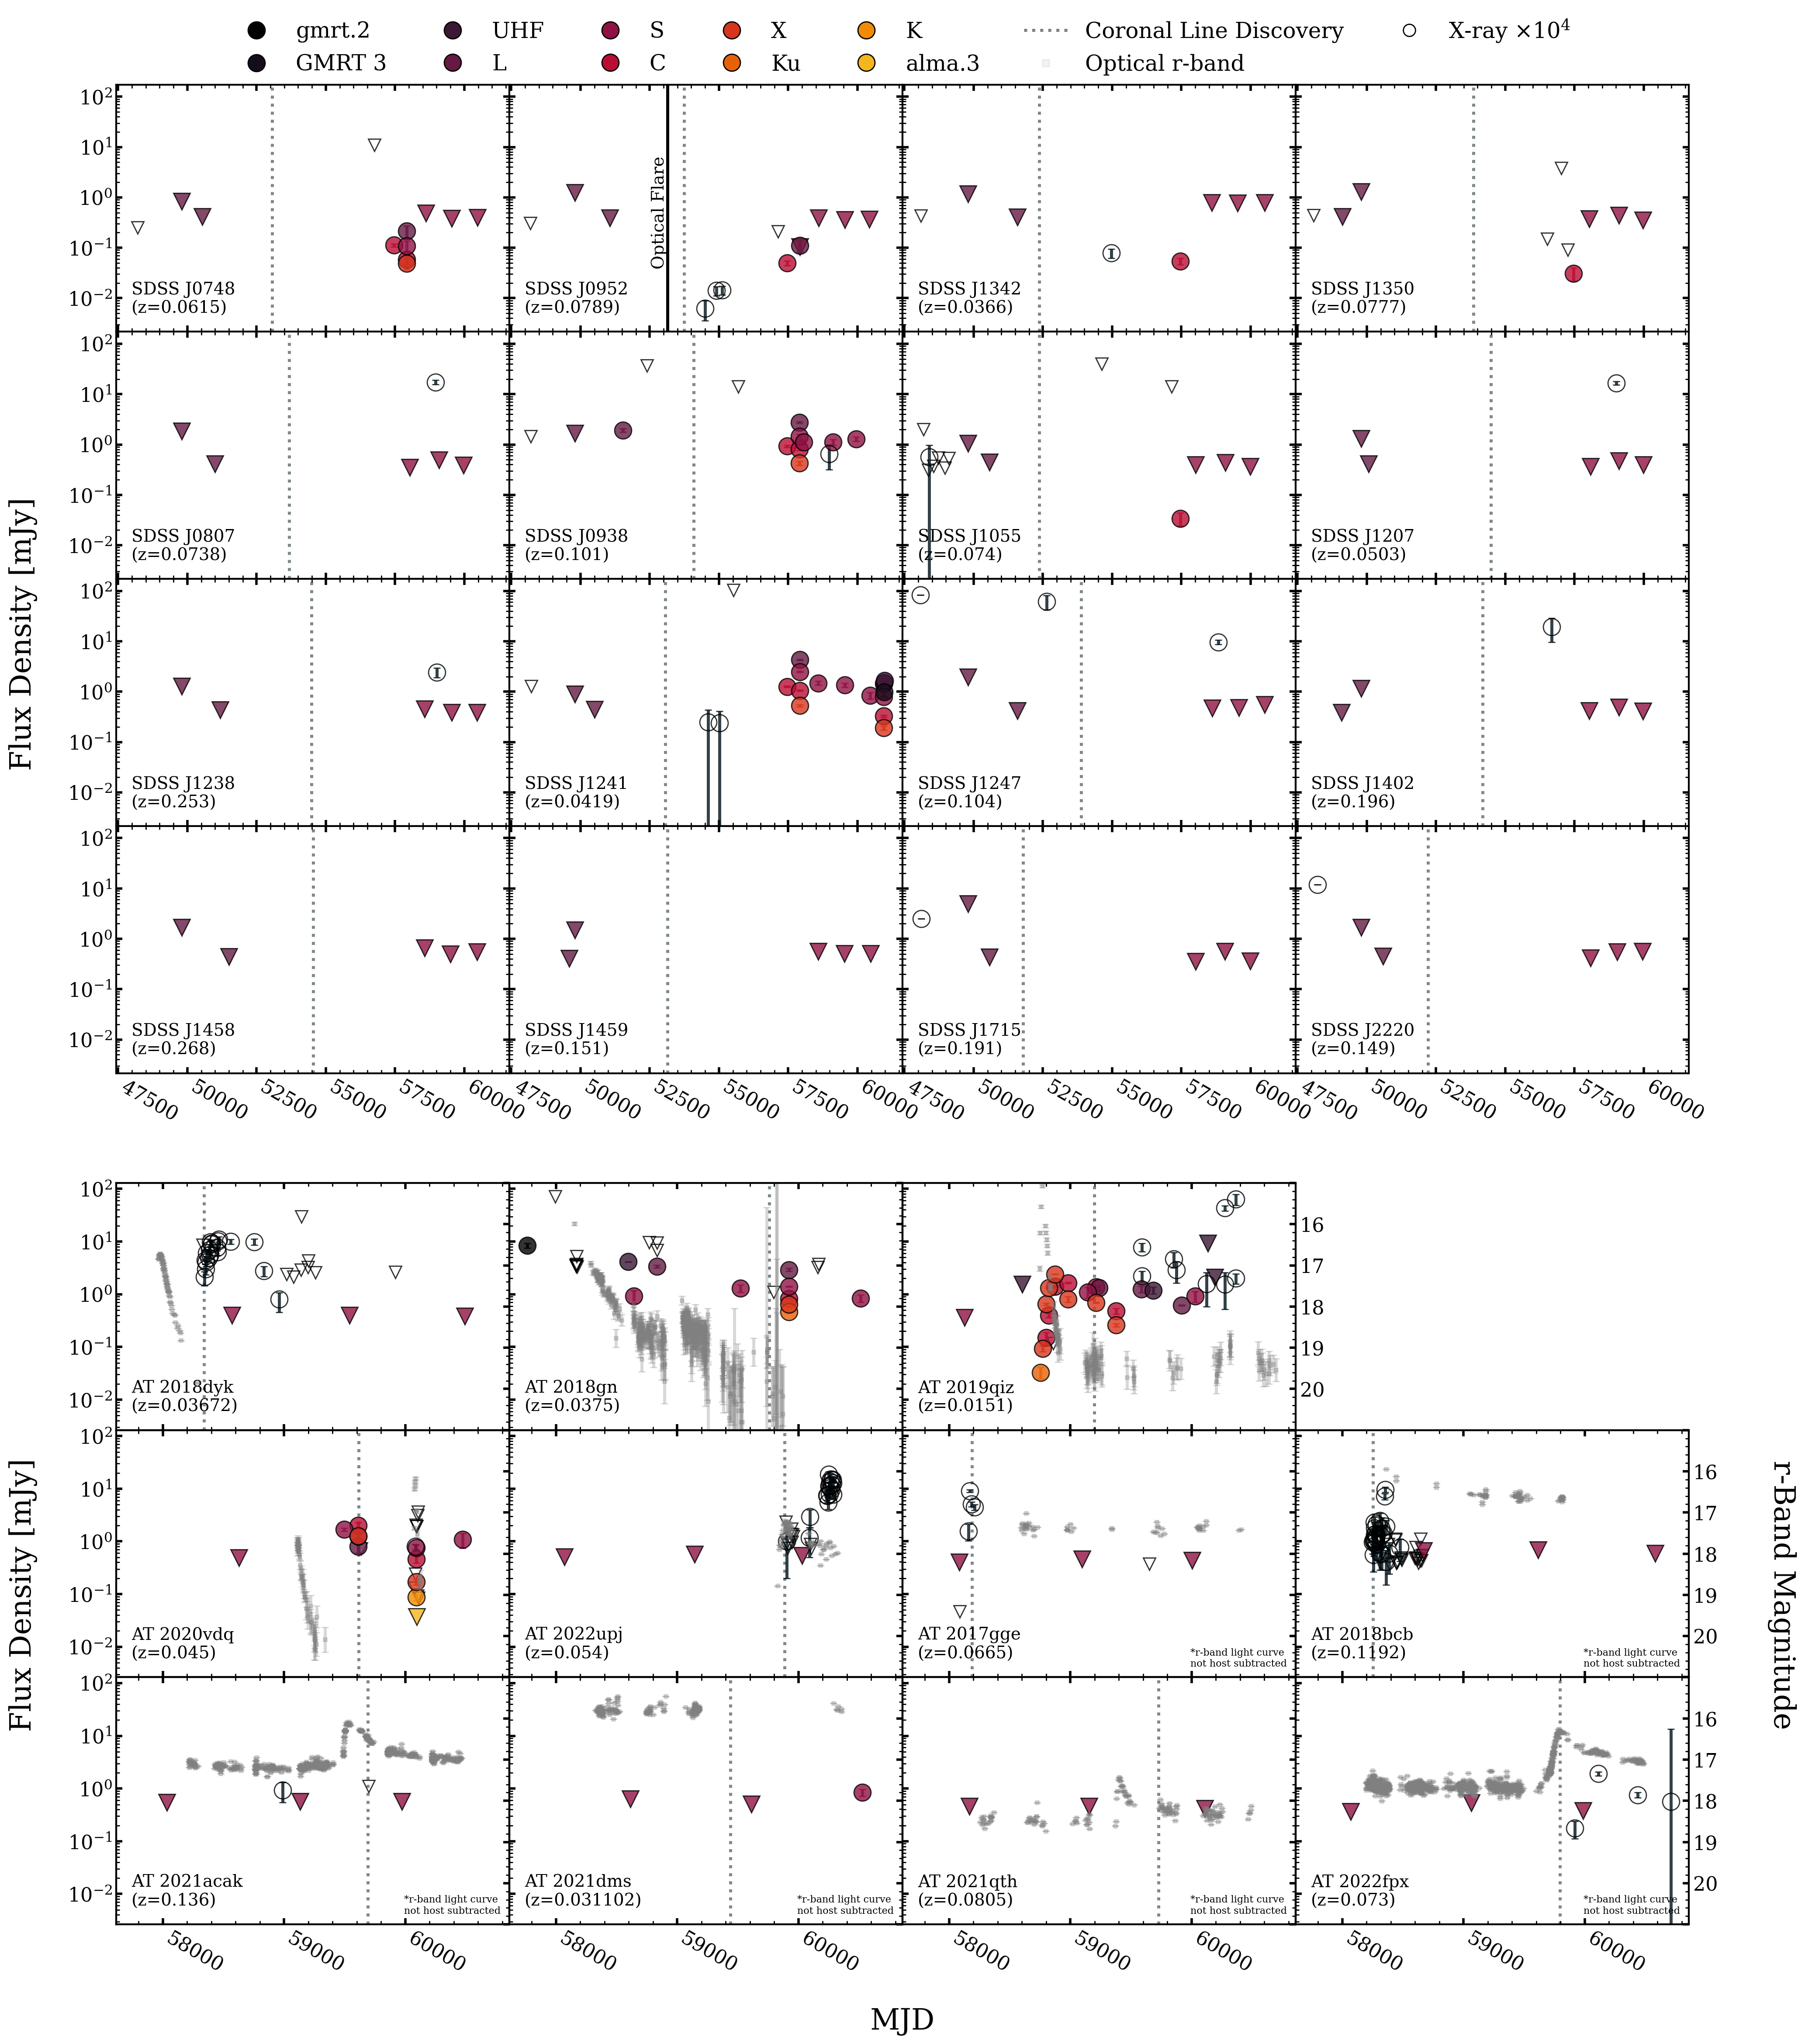

In [31]:

from matplotlib.lines import Line2D
import cmasher as cmr
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec


fig =  plt.figure(figsize=(18,22))

# fig, axs = plt.subplots(6,4,sharey=True,, sharex=True, ) #, "wspace":0})

kwargs = dict(
    sharex=True, sharey=True, gridspec_kw={"wspace":0, "hspace":0}
)
figold, fignew = fig.subfigures(2, 1, height_ratios=[4/7, 3/7], hspace=0)
fig.subplots_adjust(
    top=1, bottom=0.1,
    left=0, right=1,
    hspace=0, wspace=0
)


axs_new = centered_subplots([3,4,4], fignew) #fignew.subplots(3, 4, **kwargs)
axs_old = centered_subplots([4,4,4,4], figold) #figold.subplots(4, 4, **kwargs)

axs = list(axs_new) + list(axs_old)
left_ylabs = {0, 3, 7, 11, 15, 19, 23}
right_ylabs = {2, 6, 10}
xlabs = {7, 8, 9, 10, 23, 24, 25, 26}
xray_factor = 1e4

c = cmr.take_cmap_colors(cmr.ember, 10, cmap_range=(0,0.9))
filt_colors = {
    'gmrt.2':c[0],
    'gmrt.3':c[1],
    'UHF':c[2],
    'L':c[3],
    'S':c[4], 
    'C':c[5], 
    'X':c[6],
    'Ku':c[7],
    'K': c[8],
    'alma.3': c[9]
}
date0 = 0 #49_000 # in MJD, to normalize the x-axes

not_host_sub = ["AT2017gge", "AT2018bcb", "AT2021acak", "AT2021dms", "AT2021qth", "AT2022fpx"]

for idx, (ax, (name, grp)) in enumerate(zip(axs, radiophot.groupby("name"))):

    xray = None
    print(name, xray_data.keys())
    if name in xray_data:
        print(name, "has xrays")
        xray = xray_data[name]
    elif name.strip("AT") in xray_data:
        print(name, "has xrays")
        xray = xray_data[name.strip("AT")]
    
    
    t = db.get_meta(names=name, query_private=True)[0]
    # don't plot the side band data for the light curve
    grp = choose_fullband(grp)
    print(idx, name)
    if name in {"2018dyk", "2020vdq", "2022upj", "2018gn"}:
        name = "AT"+name
    if name.startswith("SDSS") and "_" not in name:
        name = name.replace("SDSS", "SDSS_")
    print(name)
    iso_time = ecle_meta[ecle_meta.name == name].ecl_discovery_date.values[0].strip()
    cl_date = Time(iso_time, format="iso")
    if not name.startswith("AT") and not name.startswith("SDSS"):
        name = "AT"+name
    try:
        z = t.get_redshift()
    except KeyError:
        print(f"Skipping {t.default_name}, no redshift!")
        continue

    if "AT" in name:
        # get the not host subtracted g-band light curve 
        uvoir = db.get_phot(names=name, query_private=True, return_type="pandas", obs_type="uvoir")
        rlc = uvoir[uvoir.filter_name == "r"].sort_values("converted_date") #  * (uvoir.converted_wave.astype(int) == 474)
        rlc = rlc[(~pd.isna(rlc.converted_flux)) * (np.isfinite(rlc.converted_flux))] # filter out NaN and Inf flux values
    
        # rlc.upperlimit = rlc[rlc.converted_flux_err < np.log(10) / (sigma * 2.5)]
        
        # print(name, rlc.filter_name.unique())
        rlc_dets = rlc[~rlc.upperlimit]
        rlc_lims = rlc[rlc.upperlimit]
    
        xmin = min(rlc_dets.converted_date.min(), grp.converted_date.min()) - date0
    
        twinax = ax.twinx()
        twinax.set_ylim(21, 15)
        
        twinax.errorbar(
            rlc_dets.converted_date, #xplot,
            rlc_dets.converted_flux, #bspline(xplot),
            yerr=rlc_dets.converted_flux_err,
            alpha=0.3,
            color="grey",
            zorder=1,
            linestyle="none",
            marker="s",
            ms = 3
        )        

        grp = grp[grp.converted_date > 52_000] # filter out the non-constraining NVSS+FIRST limits
        xmin = min(rlc_dets.converted_date.min(), grp.converted_date.min()) - date0
        
        # print(idx, idx%4 , name)
        labs = [""] + twinax.get_yticklabels()[1:-1] + [""]
        twinax.set_yticks(twinax.get_yticks(), labs)
        if idx not in right_ylabs:
            twinax.set_yticklabels([])

        if name in not_host_sub:
            at = AnchoredText("*r-band light curve\nnot host subtracted", 'lower right', frameon=False, prop=dict(fontsize=8))
            ax.add_artist(at)

    at = AnchoredText(name.replace("_"," ").replace("AT","AT ") + f"\n(z={z})", 'lower left', frameon=False, prop=dict(fontsize=14))
    ax.add_artist(at)

    if "J0952" in name:
        # then we should add a vertical line where the optical flare began
        ax.axvline(Time("2004-05-18", format="iso").mjd, color="k") # From https://iopscience.iop.org/article/10.3847/0004-637X/819/2/151#apj522687f1
        ax.text(Time("2004-05-18", format="iso").mjd, 0.5, "Optical Flare", va="center", ha="right", rotation=90, fontsize=14)

    ax.axvline(cl_date.mjd-date0, linestyle=":", alpha=0.5)
    for filt, subgrp in grp.groupby("filter_name"):
        
        subgrp = subgrp.sort_values("converted_date")
        dets = subgrp[~subgrp.upperlimit]
        lims = subgrp[subgrp.upperlimit]
        
        ax.errorbar(
            dets.converted_date - date0,
            dets.converted_flux,
            yerr=dets.converted_flux_err,
            marker="o",
            mec="k",
            capsize=3,
            linestyle="none",
            color = filt_colors[filt],
            markersize=14,
            alpha=0.8,
            zorder = 100
        )
        ax.plot(
            lims.converted_date - date0,
            lims.converted_flux,
            marker="v",
            mec="k",
            linestyle="none",
            color = filt_colors[filt],
            markersize=14,
            alpha=0.8, 
            zorder = 100
        )

    if xray is not None:
        dets = xray[~xray.upperlimit]
        lims = xray[xray.upperlimit]
        ax.errorbar(
            dets.converted_date - date0,
            dets.converted_flux*xray_factor,
            yerr=dets[['converted_upper', 'converted_lower']].values.T*xray_factor,
            marker="o",
            mec="k",
            capsize=3,
            linestyle="none",
            mfc='none',
            markersize=14,
            alpha=0.8,
            zorder = 100
        )
        ax.plot(
            lims.converted_date - date0,
            lims.converted_flux*xray_factor,
            marker="v",
            mec="k",
            mfc='none',
            linestyle="none",
            markersize=10,
            alpha=0.8, 
            zorder = 10
        )

    ax.set_yscale("log")

    if idx not in left_ylabs:
        ax.tick_params(labelleft=False)

    if idx not in xlabs:
        ax.tick_params(labelbottom=False)
    else:
        ax.tick_params(axis="x", labelrotation=-30)
        for lab in ax.get_xticklabels():
            lab.set_ha("left")   # or "center", "left"

    #if idx == 18:
    #    ax.get_xticklabels()[-2].set_visible(False)

    # if idx == 8:
    #     ax.get_yticklabels()[-1].set_visible(False)
    #     ax.get_yticklabels()[-2].set_visible(False)

if date0:
    fig.supxlabel(f"Days Since MJD{date0}", fontsize=24)
else:
    fig.text(0.5, 0, f"MJD", fontsize=24, ha="center", va="top")
    
fignew.text(-0.05, 0.5, "Flux Density [mJy]", fontsize=24, ha="right", va="center", rotation=90)
figold.text(-0.05, 0.5, "Flux Density [mJy]", fontsize=24, ha="right", va="center", rotation=90)

# ax.set_xlim(xmin, Time.now().mjd-(date0-400))
fig.legend(
    loc="center",
    bbox_to_anchor=(0.5,1.02),
    handles=[
        Line2D(
            [0],[0],
            marker="o", 
            mec="k",
            linestyle="none", 
            label=lab.upper() if lab.upper()=="UHF" else ("GMRT 3" if lab=="gmrt.3" else lab), 
            markersize=14,
            color=c
        ) for lab, c in filt_colors.items()
    ] + [
        Line2D(
            [0], [0],
            marker = "none",
            linestyle = ":",
            label = "Coronal Line Discovery",
            color = "k",
            alpha = 0.5
        ),
        Line2D(
            [0], [0],
            marker = "s",
            linestyle = "none",
            label = "Optical r-band",
            color = "grey",
            alpha = 0.1
        ),
        Line2D(
            [0], [0],
            marker='o',
            linestyle='none',
            label = rf'X-ray $\times10^{{{int(np.log10(xray_factor))}}}$',
            mec = 'k',
            mfc = 'none',
            alpha = 1,
            ms=10
        )
    ], 
    ncols=7, 
    fontsize=18
)

fignew.text(1.05, 0.5, "r-Band Magnitude", fontsize=24, rotation=-90, ha="left", va="center")

fig.savefig("ecle-radio-lcs.png")

0    0.564150
1    0.178400
2    1.911591
3    0.761018
Name: converted_flux, dtype: float64